# verify_pca_meta_start_times

This notebook explains exactly how `align_pca_event_meta_start_times()` works and what the PCA is aligning to.

## Core idea
- PCA bins spikes around `event_meta['start_time']`.
- `pca_event_meta` defines which trials are used and how they are labeled (`condition`, `epoch_id`, `condition_epoch`).
- `align_pca_event_meta_start_times()` remaps only the `start_time` column onto that fixed trial table.


In [71]:
from pathlib import Path
import numpy as np
import pandas as pd

import pca_data_prep as prep
import pca_plotting as plots
import verify_data as verify


## Config
Edit these paths if needed. If trial-index files are missing, this notebook falls back to bundle `pca_event_meta`.


In [72]:
# SET #1: Path to the NWB file for this session (on the neural data computer)
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")

# SET #2: Path to the bombcell root folder for this session (on the neural data computer)
BOMBCELL_ROOT_FOR_AUTO_BUILD = Path(r"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618")

# SET #3: Session name (for labeling plots)
SESSION_NAME = Path(r'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00')

# SET #4: Paths to trial index files (these are from the behavior video acquisition computer, not the neural data computer)
baseline_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_baseline_trial_numbers_tone2_aligned.npy"
washout_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_washout_trial_numbers_tone2_aligned.npy"
optoicalStim_trials_index_path = r"G:\Grant\behavior_data\DLC_net\grant_reach15_swingDoor-christie\videos\20260201\christielab\session007\20260201_christielab_session007_stim_allowed_trial_numbers_tone2_aligned.npy"


In [73]:
bundle, merged_dic, stim_df, df_stim, pca_event_meta, extras, meta, PROCESSED_BUNDLE_DIR = prep.load_or_build_processed_bundle(
    session_name=NP_FILE,
    nwb_path_for_auto_build=NWB_PATH,
    bombcell_root_for_auto_build="",
    use_bombcell_if_available=True,
    auto_build_bundle_if_missing=True,
    auto_rebuild_if_bombcell_missing=True,
    required_filenames=("merged_dic.pkl", "stim_df.pkl", "pca_event_meta.pkl"),
    verbose=True,
)

print('\n\n NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell')

baseline_trials_idx = np.load(baseline_trials_index_path, allow_pickle=True)
washout_trials_idx = np.load(washout_trials_index_path, allow_pickle=True)
optoicalStim_trials_idx = np.load(optoicalStim_trials_index_path, allow_pickle=True)

pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx,
)
meta_source = 'rebuilt_from_trial_index_files'

_stim = stim_df['stimulus'].astype(str)
tone1_start_times = stim_df.loc[_stim.eq('tone1_timestamps'), 'start_time'].to_numpy(dtype=float)
tone2_start_times = stim_df.loc[_stim.eq('tone2_timestamps'), 'start_time'].to_numpy(dtype=float)
stimROI_start_times = stim_df.loc[_stim.eq('stimROI_timestamps'), 'start_time'].to_numpy(dtype=float)
optical_start_times = stim_df.loc[_stim.eq('optical_timestamps'), 'start_time'].to_numpy(dtype=float)
all_stimROI_triggers_start_times = stim_df.loc[_stim.eq('reachInit_stimROI_timestamps'), 'start_time'].to_numpy(dtype=float)
meta_source = 'bundle_meta_fallback'

print('meta source:', meta_source)
print('pca_event_meta rows:', len(pca_event_meta))
print('pca_event_meta columns:', list(pca_event_meta.columns))
display(pca_event_meta.head(8))


Bombcell root not set. Set bombcell_root_for_auto_build to merge in_brainRegion/brain_region/bc_label.
Loaded bundle: processed_data\bundle_latest
Meta: {'created_at': '2026-02-27T17:36:14.067584', 'files': ['merged_dic.pkl', 'stim_df.pkl', 'pca_event_meta.pkl', 'extras.pkl'], 'n_probes': 6, 'n_events_stim_df': 1352824, 'n_events_pca_meta': 1352824}
pca_event_meta rows: 1352824


 NOTE: pca_event_meta key will be WRONG at this point. it gets properly built during the prep.build_pca_event_meta_and_event_times(...) call in a later cell
meta source: bundle_meta_fallback
pca_event_meta rows: 270
pca_event_meta columns: ['trial_index0', 'trial_number', 'start_time', 'condition', 'epoch_id', 'condition_epoch']


,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch
0,0,1,10239.893300,baseline,0,baseline_epoch
1,1,2,10263.343867,baseline,0,baseline_epoch
2,2,3,10285.494367,baseline,0,baseline_epoch
3,3,4,10306.931567,baseline,0,baseline_epoch
4,4,5,10383.171333,baseline,0,baseline_epoch
5,5,6,10462.971600,baseline,0,baseline_epoch
6,6,7,10484.448567,baseline,0,baseline_epoch
7,7,8,10504.645367,baseline,0,baseline_epoch


### Fix the epoch trials strcture

Total Baseline Trials:  20
Total Washout epochs:  5
Total Optical Stim epochs:  5

baseline_trials_idx [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
optoicalStim_trials_idx [list([21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40])
 list([61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80])
 list([101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120])
 list([141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160])
 list([181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270])]
washout_trials_idx [list([41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60])
 list([81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92

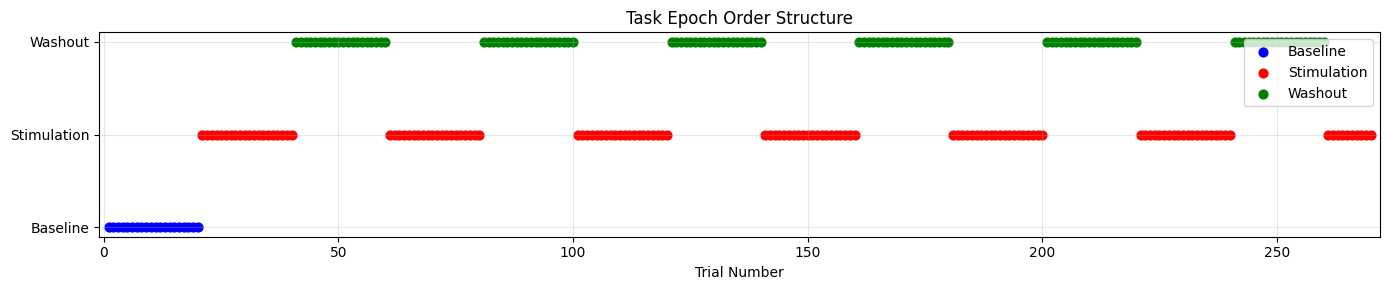

Epoch summaries (trial indices as used for verification):
  Baseline: 1..20 (n=20)
  Stim 1:  21..40 (n=20)
  Stim 2:  61..80 (n=20)
  Stim 3:  101..120 (n=20)
  Stim 4:  141..160 (n=20)
  Stim 5:  181..200 (n=20)
  Stim 6:  221..240 (n=20)
  Stim 7:  261..270 (n=10)
  Wash 1:  41..60 (n=20)
  Wash 2:  81..100 (n=20)
  Wash 3:  121..140 (n=20)
  Wash 4:  161..180 (n=20)
  Wash 5:  201..220 (n=20)
  Wash 6:  241..260 (n=20)

WARNINGS:
 - Stim epochs (7) != Wash epochs (6); checking first 6 pairs.

FAILED checks:
 - Stim epoch 7 size = 10 (expected 20).
 - Stim epochs = 7 (expected 5).
 - Wash epochs = 6 (expected 5).


In [74]:
result = verify.verify_task_epoch_structure(
    baseline_trials_idx,
    optoicalStim_trials_idx,
    washout_trials_idx,
    trials_per_epoch=20,
    expect_stim_epochs=5,
    expect_wash_epochs=5,
    auto_split_merged_epochs=True,
    split_mode="keep_incomplete",  # "raise" | "drop_incomplete" | "keep_incomplete"
    show_plot=True,
    verbose=True
)
# Overwrite with correct structure expected downstream
og_baseline_trials_idx = baseline_trials_idx
og_optoicalStim_trials_idx = optoicalStim_trials_idx
og_washout_trials_idx = washout_trials_idx

baseline_trials_idx = result["used_epochs"]["baseline"]
optoicalStim_trials_idx = result["used_epochs"]["stim"]
washout_trials_idx = result["used_epochs"]["wash"]

## Rebuild pca_event_meta with the corrected trial indices

In [75]:
pca_event_meta, tone1_start_times, tone2_start_times, stimROI_start_times, optical_start_times, all_stimROI_triggers_start_times = prep.build_pca_event_meta_and_event_times(
    stim_df=stim_df,
    baseline_trials_idx=baseline_trials_idx,
    optoicalStim_trials_idx=optoicalStim_trials_idx,
    washout_trials_idx=washout_trials_idx,
)

## Event source arrays (`_event_time_source_map`)


In [76]:
_event_time_source_map = {
    'start_time': None,
    'tone1_start_times': tone1_start_times,
    'tone2_start_times': tone2_start_times,
    'stimROI_start_times': stimROI_start_times,
    'optical_start_times': optical_start_times,
    'all_stimROI_triggers_start_times': all_stimROI_triggers_start_times,
}

for k, v in _event_time_source_map.items():
    if v is None:
        print(f"{k}: No event times available (this key is set to None)")
        continue
    arr = np.asarray(v, dtype=float).ravel()
    print(f"{k}: length={len(arr)}, example={np.round(arr[:5], 6)}")


start_time: No event times available (this key is set to None)
tone1_start_times: length=376, example=[10239.4228   10261.289967 10283.329    10304.5789   10382.2547  ]
tone2_start_times: length=270, example=[10239.9446   10263.386667 10284.956567 10305.7464   10382.945233]
stimROI_start_times: length=130, example=[10919.650067 10941.260433 10961.230467 11002.564267 11024.054767]
optical_start_times: length=1900, example=[10919.650067 10919.660067 10919.665067 10919.675067 10919.680067]
all_stimROI_triggers_start_times: length=270, example=[10239.8933   10263.343867 10285.494367 10306.931567 10383.171333]


In [77]:
print('condition counts:')
print(pca_event_meta['condition'].value_counts(dropna=False))
print('\ncondition_epoch counts:')
print(pca_event_meta['condition_epoch'].value_counts(dropna=False).sort_index())
print('\ntrial_index0 min/max:', int(pca_event_meta['trial_index0'].min()), int(pca_event_meta['trial_index0'].max()))


condition counts:
condition
stimulation    130
washout        120
baseline        20
Name: count, dtype: int64

condition_epoch counts:
condition_epoch
baseline_epoch         20
stimulation_epoch_1    20
stimulation_epoch_2    20
stimulation_epoch_3    20
stimulation_epoch_4    20
stimulation_epoch_5    20
stimulation_epoch_6    20
stimulation_epoch_7    10
washout_epoch_1        20
washout_epoch_2        20
washout_epoch_3        20
washout_epoch_4        20
washout_epoch_5        20
washout_epoch_6        20
Name: count, dtype: int64

trial_index0 min/max: 0 269


## Alignment behavior matrix
- `index`: strict `trial_index0 -> source[index]`
- `nearest`: nearest source value to original `start_time`
- `index_then_nearest`: index first, then nearest fallback


In [78]:
EVENT_TIME_ALIGN_COUNT_MODE = 'match_source_count'
EVENT_TIME_ENFORCE_SOURCE_CONDITION = True

def run_alignment(align_to, mismatch, drop_unmatched=True):
    em_aligned, report = prep.align_pca_event_meta_start_times(
        pca_event_meta=pca_event_meta,
        align_to=align_to,
        tone1_start_times=tone1_start_times,
        tone2_start_times=tone2_start_times,
        stimROI_start_times=stimROI_start_times,
        optical_start_times=optical_start_times,
        all_stimROI_triggers_start_times=all_stimROI_triggers_start_times,
        mismatch=mismatch,
        drop_unmatched=drop_unmatched,
    )

    methods = em_aligned['start_time_align_method'].astype(str).value_counts(dropna=False).to_dict() if 'start_time_align_method' in em_aligned.columns else {}
    mean_delta = float(pd.to_numeric(em_aligned.get('start_time_align_abs_delta_s'), errors='coerce').dropna().mean()) if 'start_time_align_abs_delta_s' in em_aligned.columns else np.nan

    return {
        'align_to': align_to,
        'mismatch': mismatch,
        'rows_out': int(len(em_aligned)),
        'report_unmatched_rows': report.get('unmatched_rows'),
        'mean_abs_delta_s': mean_delta,
        'method_counts': methods,
    }, em_aligned

targets = ['start_time','tone1_start_times','tone2_start_times','stimROI_start_times','optical_start_times','all_stimROI_triggers_start_times']
modes = ['index','nearest','index_then_nearest']
rows = []
errs = []
for t in targets:
    for m in modes:
        try:
            rec, _ = run_alignment(t, m, drop_unmatched=True)
            rows.append(rec)
        except Exception as e:
            errs.append({'align_to': t, 'mismatch': m, 'error': str(e)})

display(pd.DataFrame(rows))
if errs:
    print('errors:')
    display(pd.DataFrame(errs))


,align_to,mismatch,rows_out,report_unmatched_rows,mean_abs_delta_s,method_counts
0,start_time,index,270,0,0.000000,{'existing': 270}
1,start_time,nearest,270,0,0.000000,{'existing': 270}
2,start_time,index_then_nearest,270,0,0.000000,{'existing': 270}
3,tone1_start_times,index,270,0,1107.774206,{'index': 270}
4,tone1_start_times,nearest,270,0,1.702729,{'nearest': 270}
5,tone1_start_times,index_then_nearest,270,0,1107.774206,{'index': 270}
6,tone2_start_times,index,270,0,0.318036,{'index': 270}
7,tone2_start_times,nearest,270,0,0.318036,{'nearest': 270}
8,tone2_start_times,index_then_nearest,270,0,0.318036,{'index': 270}
9,stimROI_start_times,nearest,270,0,103.453572,{'nearest': 270}


errors:


,align_to,mismatch,error
0,stimROI_start_times,index,Index alignment failed for 140 rows. Source 's...


## Focus case: `stimROI_start_times` with `index_then_nearest`
If rows exceed source length, nearest fallback can keep many rows alive.


In [79]:
rec, em_demo = run_alignment('stimROI_start_times', 'index_then_nearest', drop_unmatched=True)
print('summary:', rec)

src = np.asarray(stimROI_start_times, dtype=float).ravel()
idx = pd.to_numeric(pca_event_meta['trial_index0'], errors='coerce').to_numpy()
in_range = np.isfinite(idx) & (idx >= 0) & (idx < len(src))
print('len(pca_event_meta):', len(pca_event_meta))
print('len(stimROI_start_times):', len(src))
print('strict index in-range rows:', int(in_range.sum()))

if 'start_time_align_method' in em_demo.columns:
    print('method counts:')
    print(em_demo['start_time_align_method'].value_counts(dropna=False))

show_cols = ['trial_index0','trial_number','condition','epoch_id','start_time','start_time_source','start_time_align_method','start_time_align_abs_delta_s']
show_cols = [c for c in show_cols if c in em_demo.columns]
display(em_demo[show_cols].head(20))


summary: {'align_to': 'stimROI_start_times', 'mismatch': 'index_then_nearest', 'rows_out': 270, 'report_unmatched_rows': 0, 'mean_abs_delta_s': 1200.502332839506, 'method_counts': {'nearest': 140, 'index': 130}}
len(pca_event_meta): 270
len(stimROI_start_times): 130
strict index in-range rows: 130
method counts:
start_time_align_method
nearest    140
index      130
Name: count, dtype: int64


,trial_index0,trial_number,condition,epoch_id,start_time,start_time_source,start_time_align_method,start_time_align_abs_delta_s
0,0,1,baseline,0,10919.650067,stimROI_start_times,index,679.756767
1,1,2,baseline,0,10941.260433,stimROI_start_times,index,677.916567
2,2,3,baseline,0,10961.230467,stimROI_start_times,index,675.736100
3,3,4,baseline,0,11002.564267,stimROI_start_times,index,695.632700
4,4,5,baseline,0,11024.054767,stimROI_start_times,index,640.883433
5,5,6,baseline,0,11045.184867,stimROI_start_times,index,582.213267
6,6,7,baseline,0,11072.922900,stimROI_start_times,index,588.474333
7,7,8,baseline,0,11100.381000,stimROI_start_times,index,595.735633
8,8,9,baseline,0,11144.268633,stimROI_start_times,index,617.812833
9,9,10,baseline,0,11166.265933,stimROI_start_times,index,619.673333


In [80]:
# Reproduce runner post-alignment behavior (count mode + source-condition patch)
def apply_runner_post_alignment(em_aligned, align_to, *, count_mode=EVENT_TIME_ALIGN_COUNT_MODE, enforce_source_condition=EVENT_TIME_ENFORCE_SOURCE_CONDITION):
    out = em_aligned.copy().reset_index(drop=True)
    source_name = prep._normalize_event_time_source_name(align_to)

    # Patch 1: count mode
    cm = str(count_mode).strip().lower()
    if cm not in {'preserve_aligned_rows', 'match_source_count'}:
        raise ValueError(f"Invalid count_mode={count_mode}")
    if cm == 'match_source_count' and source_name != 'start_time' and 'start_time_align_method' in out.columns:
        out = out[out['start_time_align_method'].astype(str).eq('index')].reset_index(drop=True)

    # Patch 2: source-specific condition enforcement + stimulation-sequence remap
    source_condition_map = {'stimROI_start_times': 'stimulation'}
    source_condition = source_condition_map.get(source_name, None)
    if bool(enforce_source_condition) and (source_condition is not None) and ('condition' in out.columns):
        out = out[out['condition'].astype(str).str.lower().eq(str(source_condition).lower())].reset_index(drop=True)

    if source_name == 'stimROI_start_times' and bool(enforce_source_condition) and ('condition' in pca_event_meta.columns):
        stim_src = np.asarray(stimROI_start_times, dtype=float).ravel()
        stim_rows_all = pca_event_meta[pca_event_meta['condition'].astype(str).str.lower().eq('stimulation')].sort_values('trial_index0').reset_index(drop=True)
        n_map = int(min(len(stim_rows_all), stim_src.size))
        if n_map > 0:
            stim_rows = stim_rows_all.iloc[:n_map].copy().reset_index(drop=True)
            orig_start = pd.to_numeric(stim_rows['start_time'], errors='coerce').to_numpy(dtype=float)
            new_start = stim_src[:n_map]
            stim_rows['start_time'] = new_start
            stim_rows['start_time_source'] = source_name
            stim_rows['start_time_align_method'] = 'stimulation_sequence_index'
            stim_rows['start_time_align_abs_delta_s'] = np.abs(new_start - orig_start)
            out = stim_rows
    return out

_, em_demo = run_alignment('stimROI_start_times', 'index_then_nearest', drop_unmatched=True)
em_patch = apply_runner_post_alignment(em_demo, 'stimROI_start_times')
print('rows before:', len(em_demo))
print('rows after runner patches:', len(em_patch))
if 'condition_epoch' in em_patch.columns:
    print('condition_epoch counts after runner patches:')
    print(em_patch['condition_epoch'].value_counts(dropna=False))
if 'start_time_align_method' in em_patch.columns:
    print('align method counts after runner patches:')
    print(em_patch['start_time_align_method'].value_counts(dropna=False))


rows before: 270
rows after runner patches: 130
condition_epoch counts after runner patches:
condition_epoch
stimulation_epoch_1    20
stimulation_epoch_2    20
stimulation_epoch_3    20
stimulation_epoch_4    20
stimulation_epoch_5    20
stimulation_epoch_6    20
stimulation_epoch_7    10
Name: count, dtype: int64
align method counts after runner patches:
start_time_align_method
stimulation_sequence_index    130
Name: count, dtype: int64


## Practical interpretation
- `pca_event_meta` is your PCA trial ledger (which rows, which condition/epoch).
- `_event_time_source_map` arrays are candidate timestamp sources.
- `align_pca_event_meta_start_times()` maps each trial row to one timestamp from that source.
- The PCA itself always aligns to `event_meta['start_time']` after this mapping.


### Show the direct difference between each start_time for the actual selected _event_time_source_map and the pca_event_meta start_times

In [81]:
em_patch

,trial_index0,trial_number,start_time,condition,epoch_id,condition_epoch,start_time_source,start_time_align_method,start_time_align_abs_delta_s
0,20,21,10919.650067,stimulation,1,stimulation_epoch_1,stimROI_start_times,stimulation_sequence_index,0.000067
1,21,22,10941.260433,stimulation,1,stimulation_epoch_1,stimROI_start_times,stimulation_sequence_index,0.000100
2,22,23,10961.230467,stimulation,1,stimulation_epoch_1,stimROI_start_times,stimulation_sequence_index,0.140033
3,23,24,11002.564267,stimulation,1,stimulation_epoch_1,stimROI_start_times,stimulation_sequence_index,0.000100
4,24,25,11024.054767,stimulation,1,stimulation_epoch_1,stimROI_start_times,stimulation_sequence_index,0.000100
...,...,...,...,...,...,...,...,...,...
125,265,266,18693.912133,stimulation,7,stimulation_epoch_7,stimROI_start_times,stimulation_sequence_index,0.000100
126,266,267,18714.659100,stimulation,7,stimulation_epoch_7,stimROI_start_times,stimulation_sequence_index,0.481933
127,267,268,18744.247367,stimulation,7,stimulation_epoch_7,stimROI_start_times,stimulation_sequence_index,1.146867
128,268,269,18764.850833,stimulation,7,stimulation_epoch_7,stimROI_start_times,stimulation_sequence_index,0.807467


In [82]:
count = 0
def compare_start_times(em_aligned, source_times, source_name):
    global count
    aligned_times = pd.to_numeric(em_aligned['start_time'], errors='coerce').to_numpy(dtype=float)
    source_times = np.asarray(source_times, dtype=float).ravel()
    print(f"Comparing aligned start times to source '{source_name}' times:")
    print(f"Aligned start times: length={len(aligned_times)}, example={np.round(aligned_times[:5], 6)}")
    print(f"Source '{source_name}' times: length={len(source_times)}, example={np.round(source_times[:5], 6)}")
    difference_in_seconds = aligned_times - source_times[:len(aligned_times)]
    print(difference_in_seconds)

compare_start_times(em_patch, stimROI_start_times, 'stimROI_start_times')

Comparing aligned start times to source 'stimROI_start_times' times:
Aligned start times: length=130, example=[10919.650067 10941.260433 10961.230467 11002.564267 11024.054767]
Source 'stimROI_start_times' times: length=130, example=[10919.650067 10941.260433 10961.230467 11002.564267 11024.054767]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
